# Phase 4 — Splitting, and the leak it exposes

The brief asks for a stint-based split and says a random split would leak. This phase does
both, and measures the size of the leak rather than asserting it.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))

pd.set_option("display.width", 130)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9})

from cleaning import clean
from data_loader import load_pit_stops
from dataset import build_lap_table
from features import add_features
from splits import assert_disjoint, neighbour_leakage, random_split, split_summary, stint_split

race, selected, laps = build_lap_table()
stops = load_pit_stops()
stops = stops[stops["raceId"] == race["raceId"]]
featured = add_features(clean(laps, stops)[0], stops)
print(f"{len(featured)} laps to split")

410 laps to split


## The two splits

**Stint split.** Each driver's final stint is held out; everything before it trains. A stint
is a contiguous block of laps on one set of tires, so holding one out asks the model to
predict a run of the race it has never seen.

**Random split.** Laps shuffled and cut 80/20, which is what a default `train_test_split`
call produces. It is kept only so its failure can be measured.

In [2]:
summary = split_summary(featured)
summary

,split,train_laps,test_laps,test_share,test_tire_age_min,test_tire_age_max,neighbour_in_train
0,stint,248,162,0.395,1,34,0.000
1,random,328,82,0.200,1,30,0.951


## Measuring the leak

`neighbour_in_train` is the share of test laps whose immediately adjacent lap sits in the
training set. It names the mechanism directly.

Consecutive laps by the same driver on the same set of tires differ by a few tenths of a
second. If lap 23 and lap 25 are both in training, then predicting lap 24 is not prediction.
It is interpolation between two nearly identical points, and any model will look excellent
at it.

| Split | Test laps with a neighbour in training |
| :-- | --: |
| Stint | **0.0%** |
| Random | **95.1%** |

The stint split scores exactly zero by construction: a held-out stint is bounded by a pit
stop on one side and the end of the race on the other, and cleaning already removed the laps
at those boundaries. Nothing adjacent survives in training.

In [3]:
s_train, s_test = stint_split(featured)
r_train, r_test = random_split(featured)

assert_disjoint(s_train, s_test)
assert_disjoint(r_train, r_test)
print("no lap appears in both train and test, for either split")

print(f"\nstint  : {neighbour_leakage(s_train, s_test):.1%} of test laps have a neighbour in train")
print(f"random : {neighbour_leakage(r_train, r_test):.1%} of test laps have a neighbour in train")

no lap appears in both train and test, for either split

stint  : 0.0% of test laps have a neighbour in train
random : 95.1% of test laps have a neighbour in train


## What each split actually looks like

One row per driver, one cell per lap.

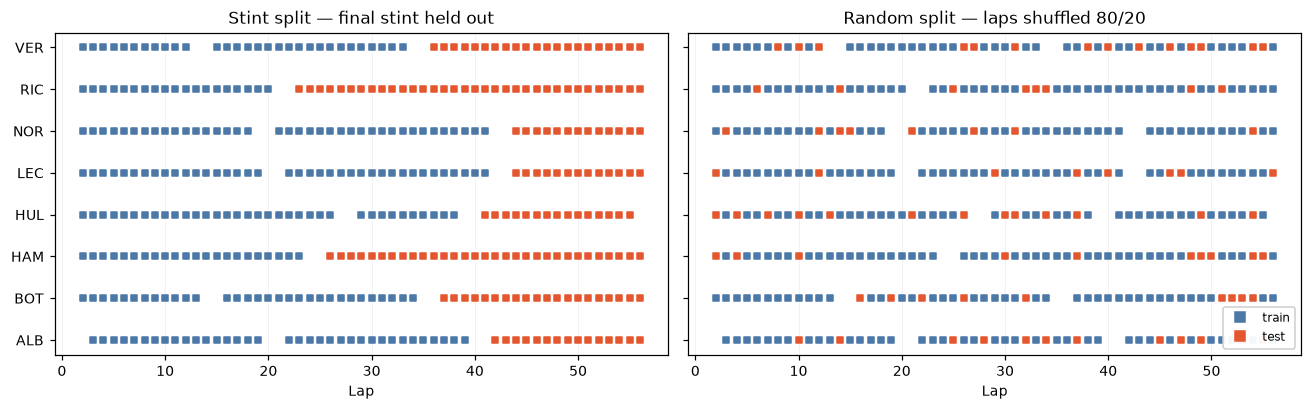

In [4]:
codes = sorted(featured["code"].unique())
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)

TRAIN_C, TEST_C = "#4C78A8", "#E4572E"

for ax, (title, train, test) in zip(axes, [
    ("Stint split — final stint held out", s_train, s_test),
    ("Random split — laps shuffled 80/20", r_train, r_test),
]):
    for y, code in enumerate(codes):
        tr = train[train["code"] == code]
        te = test[test["code"] == code]
        ax.scatter(tr["lap"], [y] * len(tr), marker="s", s=14, color=TRAIN_C)
        ax.scatter(te["lap"], [y] * len(te), marker="s", s=14, color=TEST_C)
    ax.set_yticks(range(len(codes)))
    ax.set_yticklabels(codes)
    ax.set_xlabel("Lap")
    ax.set_title(title)
    ax.grid(axis="x", alpha=0.2, lw=0.5)
    ax.set_axisbelow(True)

handles = [
    plt.Line2D([], [], marker="s", ls="", color=TRAIN_C, label="train"),
    plt.Line2D([], [], marker="s", ls="", color=TEST_C, label="test"),
]
axes[1].legend(handles=handles, loc="lower right", fontsize=8, framealpha=0.95)
fig.tight_layout()
fig.savefig(ROOT / "figures" / "04_split_structure.png", dpi=150, bbox_inches="tight")
plt.show()

The left panel holds out a solid block at the end of each driver's race. The right panel
scatters test laps through the field, each one surrounded by training laps. That picture is
the leak.

### A cost the stint split pays honestly

The stint split puts 39.5% of laps in the test set rather than the usual 20%, because a final
stint is simply a large share of a race. It also asks the model to extrapolate: the held-out
stints reach a tire age of 34, beyond much of what the training stints cover. Both make the
stint split look worse on paper. Both are the reason its score can be believed.

In [5]:
per_driver = pd.DataFrame({
    "train_laps": s_train.groupby("code").size(),
    "test_laps": s_test.groupby("code").size(),
    "held_out_stint": s_test.groupby("code")["stint_number"].max(),
    "test_tire_age_max": s_test.groupby("code")["tire_age"].max(),
}).astype(int)

summary.to_csv(ROOT / "results" / "split_summary.csv", index=False)
per_driver.to_csv(ROOT / "results" / "split_per_driver.csv")
per_driver

,train_laps,test_laps,held_out_stint,test_tire_age_max
code,,,,
ALB,35,15,4,15
BOT,31,20,3,20
HAM,22,31,2,31
HUL,35,15,3,15
LEC,38,13,3,13
NOR,38,13,3,13
RIC,19,34,2,34
VER,30,21,3,21


---

**Phase 4 complete.** Every driver contributes a held-out final stint, and no lap appears in
both sets under either split. Phase 5 runs identical models through both, so the gap between
their scores measures the illusion rather than describing it.